## Nvidia 30-Day Forward Return Prediction
Predict whether Nvidia’s next 30 trading day return is positive or negative using daily OHLCV data from 1999–2025.

- **Target:** 30-day forward return direction
- **Label `0`:** negative or zero return
- **Label `1`:** positive return
- **Data:** daily Open, High, Low, Close, Adjusted Close, Volume
- **Task:** binary classification of 30-day forward returns

## Data Preparation: Library Imports

This cell initializes all required libraries for data handling, visualization, and modeling.

- **pandas, numpy** → data manipulation and numerical operations  
- **matplotlib, seaborn** → exploratory data visualization  
- **scikit-learn** → preprocessing, model training, and evaluation  

These tools form the foundation for building and evaluating the stock return prediction pipeline.

In [414]:
# Import core data and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling imports are included here for later steps, but this cell focuses on data loading/preparation
from sklearn.preprocessing import StandardScaler
import sklearn.model_selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

# Technical-analysis helper library
import ta

# Suppress warnings to keep output clean during exploration
import warnings
warnings.filterwarnings('ignore')

# ===== LOAD DATA =====
# Read Nvidia OHLCV data from CSV
# This is the raw input for the CRISP-DM Data Understanding step
# We will convert the date column and sort chronologically

df = pd.read_csv("NVDA.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(df.info())
print(f"Data shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}\n")


<class 'pandas.DataFrame'>
RangeIndex: 6558 entries, 0 to 6557
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6558 non-null   datetime64[us]
 1   Adj Close  6558 non-null   float64       
 2   Close      6558 non-null   float64       
 3   High       6558 non-null   float64       
 4   Low        6558 non-null   float64       
 5   Open       6558 non-null   float64       
 6   Volume     6558 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 358.8 KB
None
Data shape: (6558, 7)
Date range: 1999-01-22 00:00:00 to 2025-02-14 00:00:00



## Data Understanding: Data Quality & Initial Exploration

This step validates the dataset and provides a quick statistical overview before modeling.

- Check structure (columns, rows, duplicates, missing values)  
- Review sample data and summary statistics  
- Compute daily returns to capture price movement  
- Visualize distributions of returns and volume  

This ensures the data is clean and gives an initial sense of volatility and trading behavior.

Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
Row count: 6558
Unique dates: 6558
Duplicate dates: 0

Missing values by column:
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Data sample:


,Date,Adj Close,Close,High,Low,Open,Volume
0,1999-01-22,0.037615,0.041016,0.048828,0.038802,0.043750,2714688000
1,1999-01-25,0.041556,0.045313,0.045833,0.041016,0.044271,510480000
2,1999-01-26,0.038331,0.041797,0.046745,0.041146,0.045833,343200000
3,1999-01-27,0.038212,0.041667,0.042969,0.039583,0.041927,244368000
4,1999-01-28,0.038092,0.041536,0.041927,0.041276,0.041667,227520000


,Date,Adj Close,Close,High,Low,Open,Volume
6553,2025-02-10,133.570007,133.570007,135.000000,129.960007,130.089996,216989100
6554,2025-02-11,132.800003,132.800003,134.479996,131.020004,132.580002,178902400
6555,2025-02-12,131.139999,131.139999,132.240005,129.080002,130.020004,160278600
6556,2025-02-13,135.289993,135.289993,136.500000,131.169998,131.559998,197430000
6557,2025-02-14,138.850006,138.850006,139.250000,135.500000,136.479996,194892300



Numeric summary:


,count,mean,min,25%,50%,75%,max,std
Date,6558,2012-02-02 07:47:15.864592,1999-01-22 00:00:00,2005-07-29 18:00:00,2012-02-01 12:00:00,2018-08-07 18:00:00,2025-02-14 00:00:00,NaN
Adj Close,6558.0,8.768532,0.031286,0.257739,0.437176,4.597059,149.429993,23.907205
Close,6558.0,8.795447,0.034115,0.281042,0.466083,4.644625,149.429993,23.904882
High,6558.0,8.956567,0.035547,0.288511,0.472875,4.724,153.130005,24.349618
Low,6558.0,8.618315,0.033333,0.273354,0.45925,4.58875,147.820007,23.4192
Open,6558.0,8.79585,0.034896,0.28081,0.466584,4.632437,153.029999,23.922708
Volume,6558.0,599110328.697774,19680000.0,338478000.0,500263500.0,730700250.0,9230856000.0,430723588.842055



Daily return summary:


count    6557.0000
mean        0.1963
std         3.7818
min       -35.2336
25%        -1.6282
50%         0.1308
75%         1.8405
max        42.4148
Name: daily_return, dtype: float64

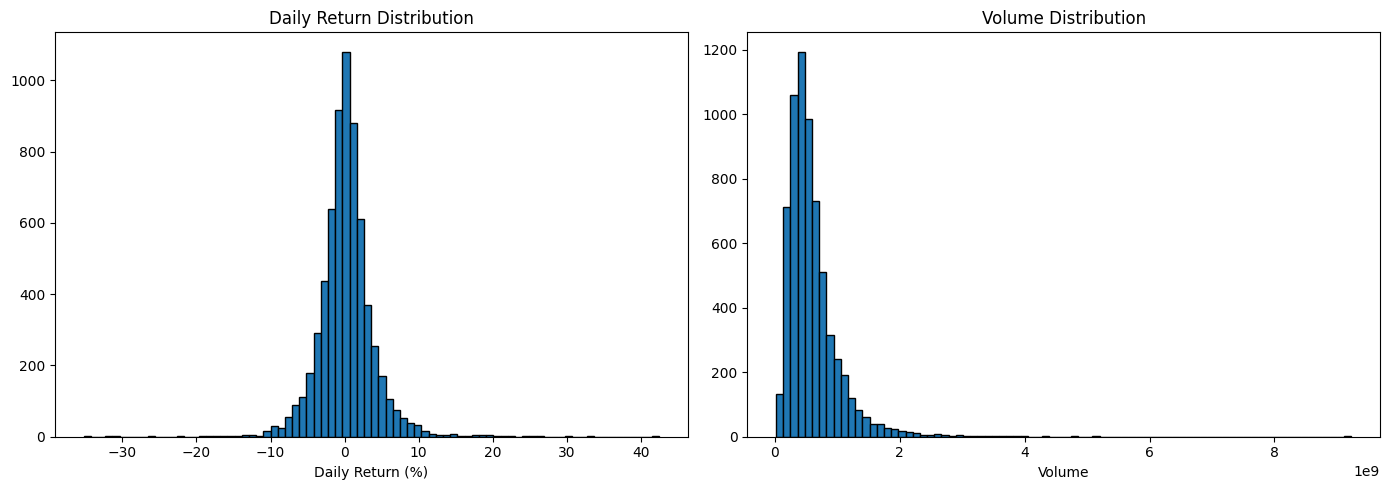

In [415]:
# ===== DATA UNDERSTANDING =====
# Inspect raw Nvidia OHLCV data before any target or feature engineering

print("Columns:", df.columns.tolist())
print("Row count:", len(df))
print("Unique dates:", df["Date"].nunique())
print("Duplicate dates:", df["Date"].duplicated().sum())
print("\nMissing values by column:")
print(df.isna().sum())

print("\nData sample:")
display(df.head())
display(df.tail())

print("\nNumeric summary:")
display(df.describe().T)

# Add a daily return column for understanding volatility
df["daily_return"] = df["Adj Close"].pct_change() * 100

print("\nDaily return summary:")
display(df["daily_return"].describe().round(4))

# Basic visual checks
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df["daily_return"].dropna(), bins=80, edgecolor="k")
plt.title("Daily Return Distribution")
plt.xlabel("Daily Return (%)")

plt.subplot(1, 2, 2)
plt.hist(df["Volume"].dropna(), bins=80, edgecolor="k")
plt.title("Volume Distribution")
plt.xlabel("Volume")

plt.tight_layout()
plt.show()

## Data Understanding: Time-Series Trends & Volatility

This step visualizes key time-series patterns and volatility in Nvidia stock data.

- Plot adjusted closing price to observe long-term trends  
- Analyze trading volume over time  
- Compute rolling volatility (30-day) to capture risk patterns  
- Examine monthly return patterns using a heatmap  

This helps identify trends, seasonality, and periods of high market volatility.

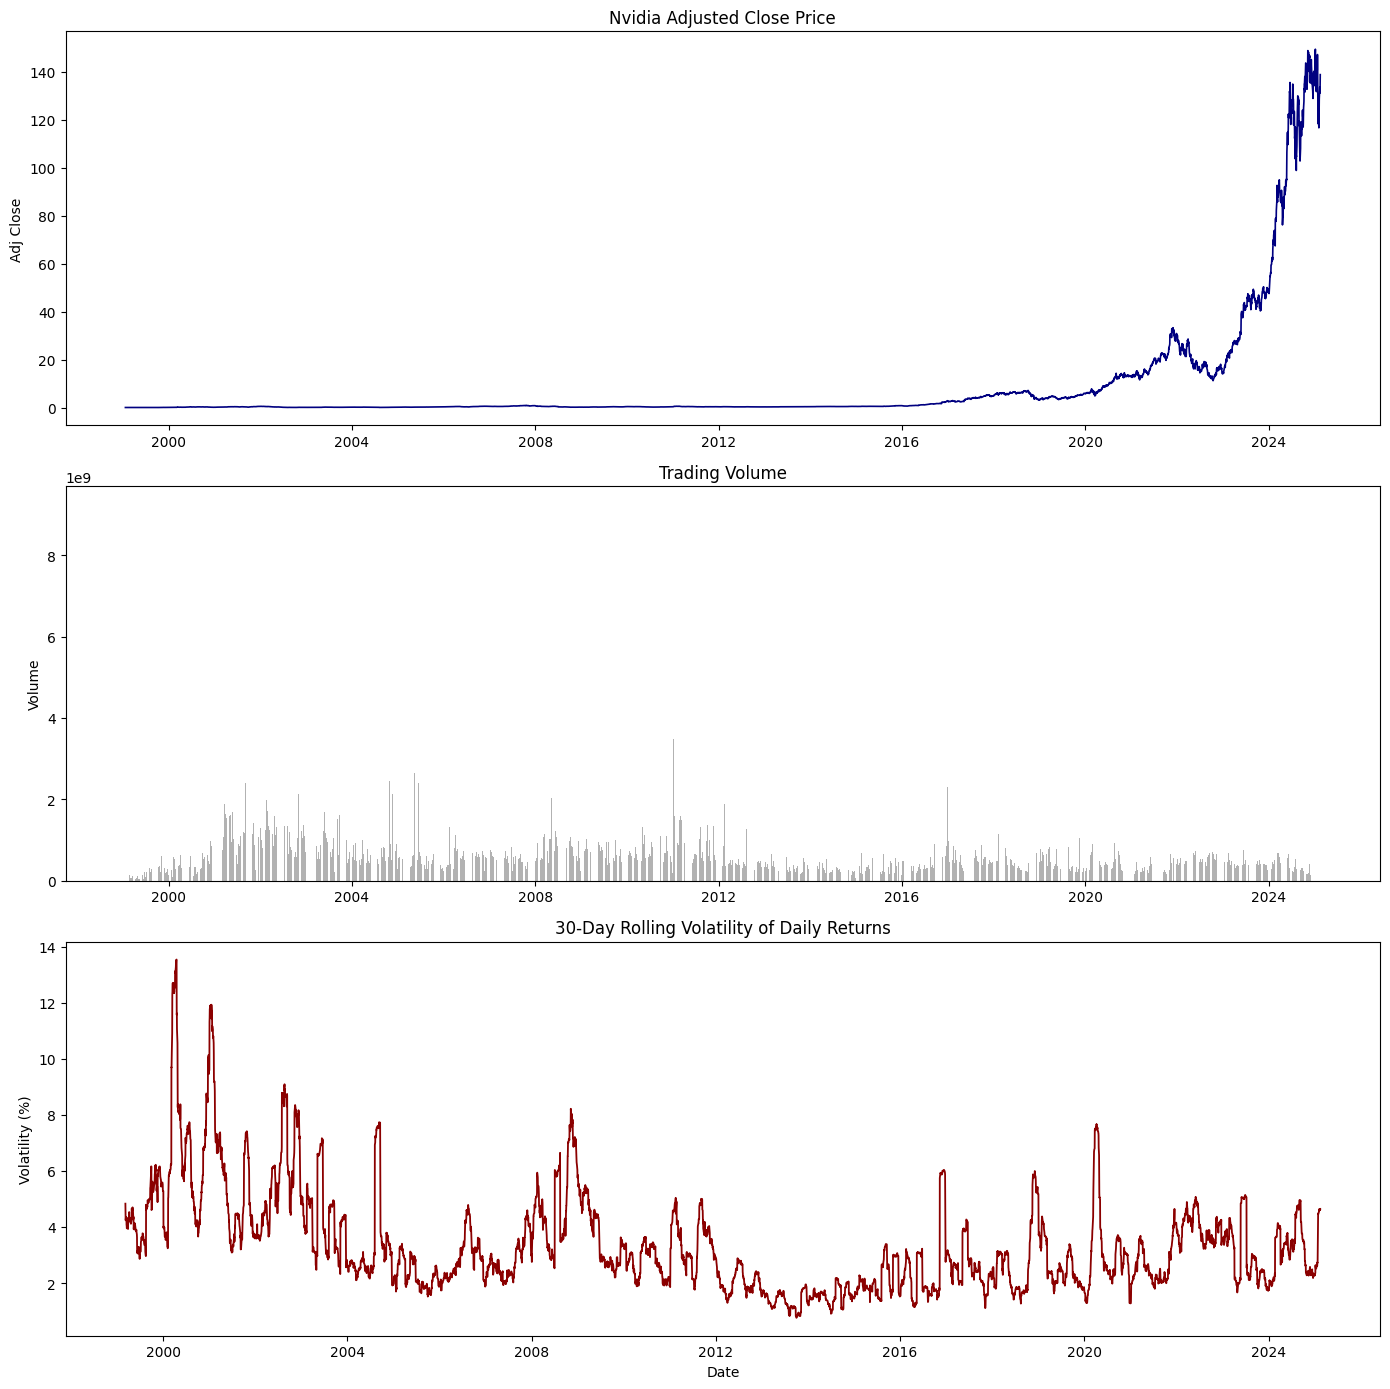

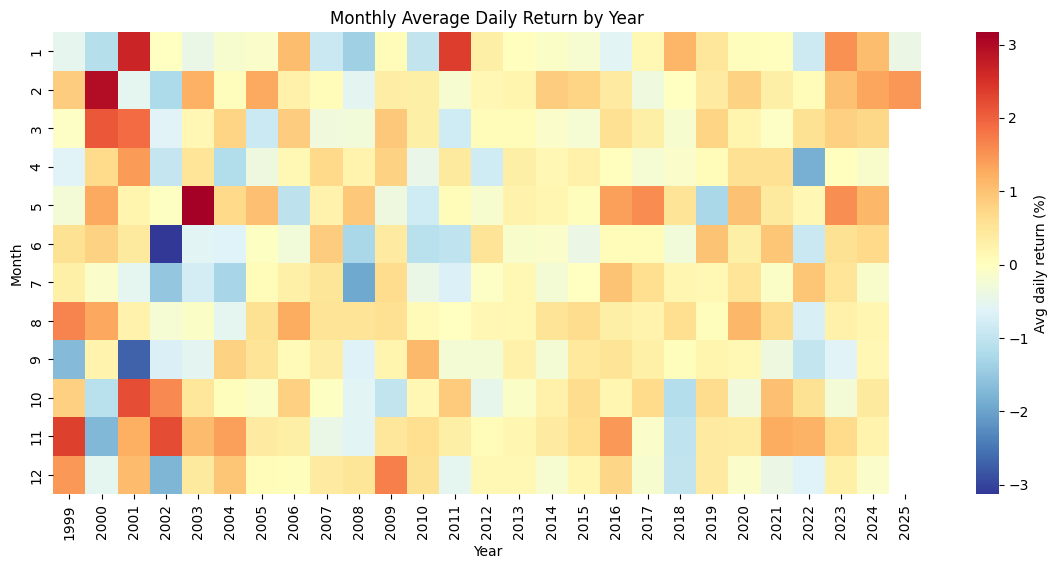

Date                0
Adj Close           0
Close               0
High                0
Low                 0
Open                0
Volume              0
daily_return        1
rolling_vol_30d    30
month               0
year                0
dtype: int64

In [416]:
# ===== DATA UNDERSTANDING VISUALIZATION =====

df["daily_return"] = df["Adj Close"].pct_change() * 100
df["rolling_vol_30d"] = df["daily_return"].rolling(30).std()
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=False)

axes[0].plot(df["Date"], df["Adj Close"], color="navy", linewidth=1.2)
axes[0].set_title("Nvidia Adjusted Close Price")
axes[0].set_ylabel("Adj Close")

axes[1].bar(df["Date"], df["Volume"], color="gray", alpha=0.6)
axes[1].set_title("Trading Volume")
axes[1].set_ylabel("Volume")

axes[2].plot(df["Date"], df["rolling_vol_30d"], color="darkred", linewidth=1.3)
axes[2].set_title("30-Day Rolling Volatility of Daily Returns")
axes[2].set_ylabel("Volatility (%)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()


monthly_avg = df.groupby(["year", "month"])["daily_return"].mean().unstack(level=0)
plt.figure(figsize=(14, 6))
sns.heatmap(monthly_avg, cmap="RdYlBu_r", center=0, annot=False, cbar_kws={"label": "Avg daily return (%)"})
plt.title("Monthly Average Daily Return by Year")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()
df.isna().sum()

## Data Preparation: Target Variable Construction

This step defines the prediction target using a 30-day forward return.

- Compute 30-day forward return (ROC) in percentage terms  
- Convert returns into a binary target using a 0.02% threshold  
- Remove trailing rows with undefined future values  

This prepares the dataset for supervised classification.

In [417]:
horizon = 30

# Forward 30-day return (ROC in %)
df["roc_30d"] = (
    (df["Adj Close"].shift(-horizon) - df["Adj Close"]) 
    / df["Adj Close"]
) * 100

# Binary target (1 = return > 0.02%, 0 otherwise)
threshold = 0.02
df["target"] = np.where(df["roc_30d"] > threshold, 1, 0)
# Remove rows with undefined future returns
df = df.iloc[:-horizon]


## Data Understanding: Target Distribution

This step examines the behavior of the constructed target variable.

- Evaluate class distribution (positive vs non-positive returns)  
- Analyze distribution of 30-day forward returns  

This helps assess class balance and the separability of the prediction target.

Target Counts:
 target
1    4026
0    2502
Name: count, dtype: int64

Target Distribution (%):
 target
1    61.672794
0    38.327206
Name: proportion, dtype: float64


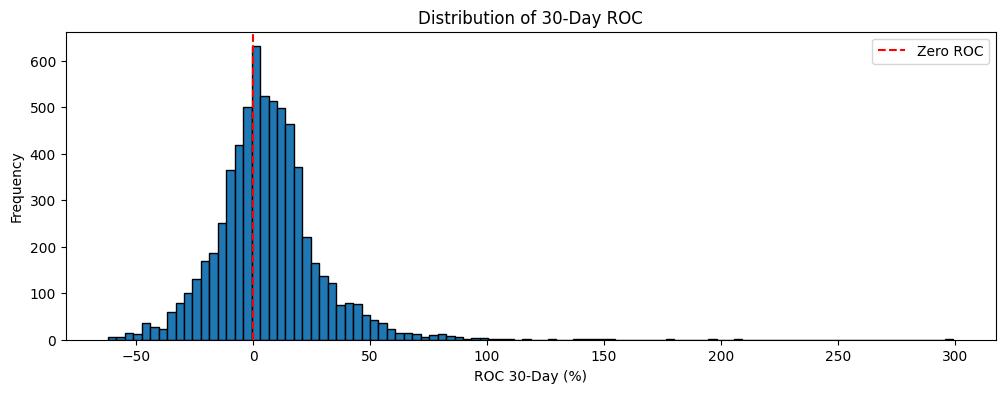

In [418]:
# Target distribution (counts and percentage)
target_counts = df["target"].value_counts()
target_percent = df["target"].value_counts(normalize=True) * 100

print("Target Counts:\n", target_counts)
print("\nTarget Distribution (%):\n", target_percent)

# ROC distribution
plt.figure(figsize=(12, 4))
plt.hist(df["roc_30d"].dropna(), bins=100, edgecolor='black')
plt.xlabel("ROC 30-Day (%)")
plt.ylabel("Frequency")
plt.title("Distribution of 30-Day ROC")
plt.axvline(x=0, color='red', linestyle='--', label='Zero ROC')
plt.legend()
plt.show()

## Data Understanding: Target Behavior Over Time

This step visualizes the target variable across time.

- Scatter plot shows individual target values (0 = negative, 1 = positive)  
- Color coding highlights class distribution over time  

This helps identify temporal patterns and clustering of positive and negative return periods.

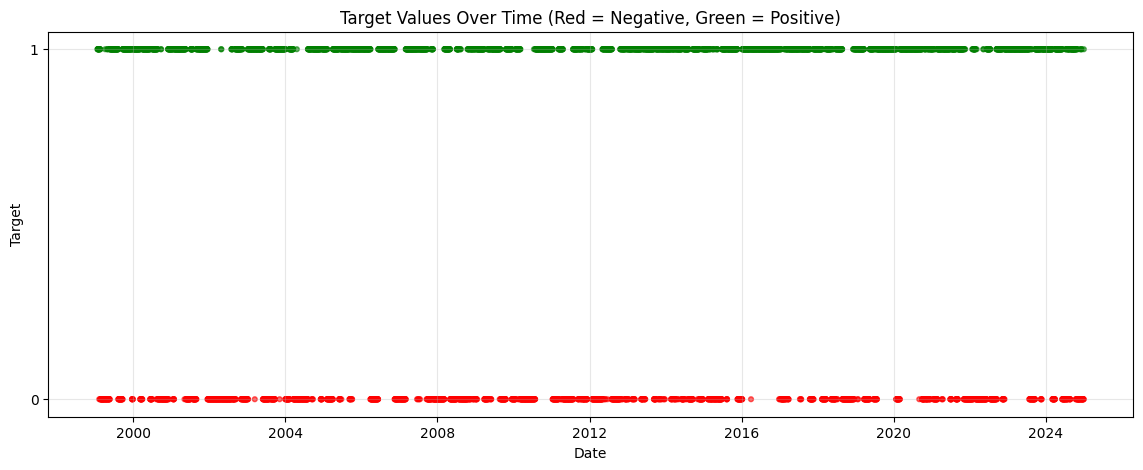

In [419]:
plt.figure(figsize=(14,5))

colors = df["target"].map({0: "red", 1: "green"})

plt.scatter(
    df["Date"], 
    df["target"], 
    c=colors, 
    alpha=0.6, 
    s=12
)

plt.yticks([0,1])
plt.title("Target Values Over Time (Red = Negative, Green = Positive)")
plt.xlabel("Date")
plt.ylabel("Target")
plt.grid(alpha=0.3)

plt.show()

## Data Understanding: Streak Length Analysis

This step analyzes consecutive sequences of positive (1) and negative (0) returns.

- Compute streak lengths of consecutive values  
- Evaluate average streak lengths and maximum streak lengths  
- Visualize full distribution of streak lengths  

This helps identify persistence, regime behavior, and temporal dependence in stock returns.

===== STREAK SUMMARY =====

Positive Returns (1s):
Avg Length        : 15.91
Max Length        : 187

Negative Returns (0s):
Avg Length        : 9.93
Max Length        : 90


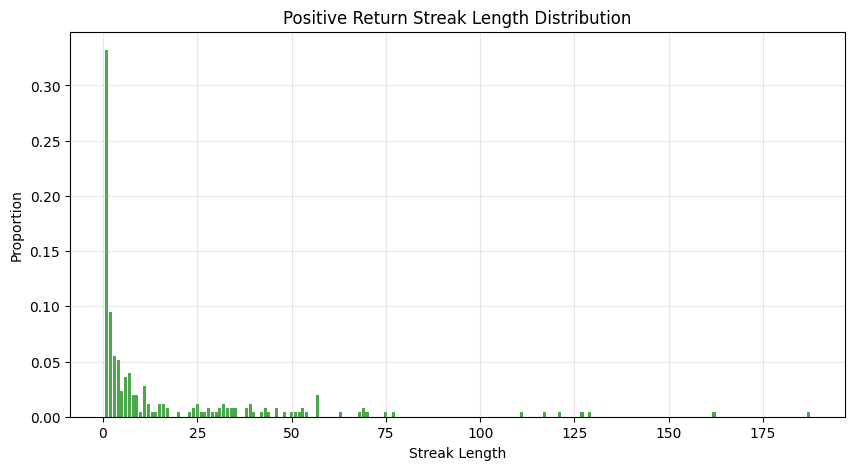

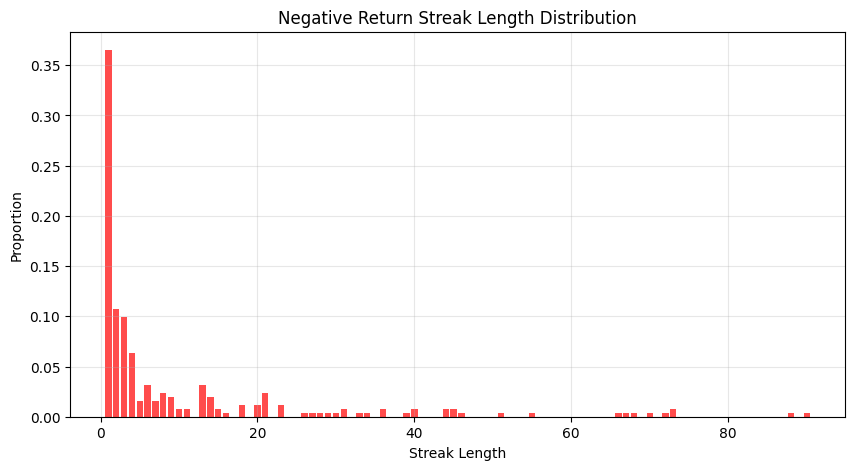

In [420]:
# ===== ANALYZE CONSECUTIVE 1s AND 0s =====

def analyze_streaks(series):
    """
    Analyze consecutive occurrences of same value in a series.
    Returns streak lengths for 1s and 0s.
    """
    clean_series = series.dropna().reset_index(drop=True)

    streaks_1, streaks_0 = [], []

    current_value = clean_series.iloc[0]
    current_streak = 1

    for i in range(1, len(clean_series)):
        if clean_series.iloc[i] == current_value:
            current_streak += 1
        else:
            if current_value == 1:
                streaks_1.append(current_streak)
            else:
                streaks_0.append(current_streak)

            current_value = clean_series.iloc[i]
            current_streak = 1

    # Append last streak
    if current_value == 1:
        streaks_1.append(current_streak)
    else:
        streaks_0.append(current_streak)

    return streaks_1, streaks_0


# ---- Compute streaks ----
streaks_1, streaks_0 = analyze_streaks(df["target"])


# ---- Convert to distributions ----
streak_1_counts = pd.Series(streaks_1).value_counts().sort_index()
streak_0_counts = pd.Series(streaks_0).value_counts().sort_index()

streak_1_dist = streak_1_counts / streak_1_counts.sum()
streak_0_dist = streak_0_counts / streak_0_counts.sum()


# ---- Summary statistics ----
avg_1 = np.mean(streaks_1)
avg_0 = np.mean(streaks_0)


max_1, max_0 = max(streaks_1), max(streaks_0)

print("===== STREAK SUMMARY =====")

print("\nPositive Returns (1s):")
print(f"Avg Length        : {avg_1:.2f}")
print(f"Max Length        : {max_1}")

print("\nNegative Returns (0s):")
print(f"Avg Length        : {avg_0:.2f}")
print(f"Max Length        : {max_0}")


# ---- Plot: FULL distributions (no truncation) ----

# Positive streaks
plt.figure(figsize=(10,5))
plt.bar(streak_1_dist.index, streak_1_dist.values, color="green", alpha=0.7)
plt.title("Positive Return Streak Length Distribution")
plt.xlabel("Streak Length")
plt.ylabel("Proportion")
plt.grid(alpha=0.3)
plt.show()


# Negative streaks
plt.figure(figsize=(10,5))
plt.bar(streak_0_dist.index, streak_0_dist.values, color="red", alpha=0.7)
plt.title("Negative Return Streak Length Distribution")
plt.xlabel("Streak Length")
plt.ylabel("Proportion")
plt.grid(alpha=0.3)
plt.show()

## Data Understanding: Yearly Target Distribution

This analysis examines how the proportion of positive (1) and negative (0) returns evolves over time.

- Aggregate target values by year  
- Compute both counts and percentage distributions  
- Visualize yearly trends to identify shifts in market behavior  

This helps detect temporal patterns, class imbalance variations, and potential regime changes in the data.

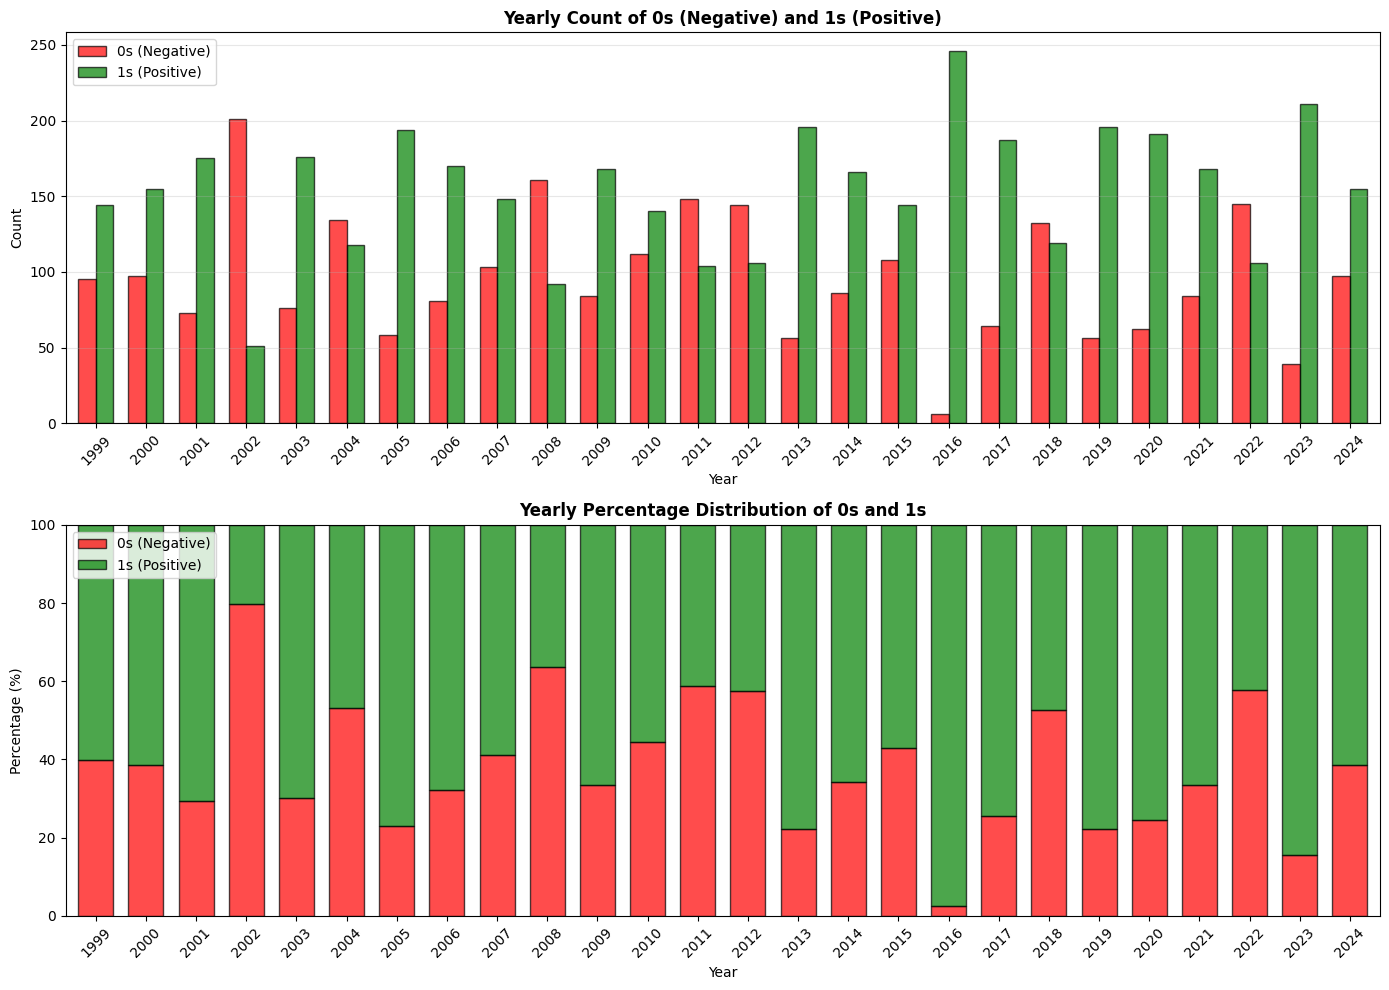


YEARLY SUMMARY

1999:
  Total days: 239
  Positive (1s): 144 days (60.3%)
  Negative (0s): 95 days (39.7%)

2000:
  Total days: 252
  Positive (1s): 155 days (61.5%)
  Negative (0s): 97 days (38.5%)

2001:
  Total days: 248
  Positive (1s): 175 days (70.6%)
  Negative (0s): 73 days (29.4%)

2002:
  Total days: 252
  Positive (1s): 51 days (20.2%)
  Negative (0s): 201 days (79.8%)

2003:
  Total days: 252
  Positive (1s): 176 days (69.8%)
  Negative (0s): 76 days (30.2%)

2004:
  Total days: 252
  Positive (1s): 118 days (46.8%)
  Negative (0s): 134 days (53.2%)

2005:
  Total days: 252
  Positive (1s): 194 days (77.0%)
  Negative (0s): 58 days (23.0%)

2006:
  Total days: 251
  Positive (1s): 170 days (67.7%)
  Negative (0s): 81 days (32.3%)

2007:
  Total days: 251
  Positive (1s): 148 days (59.0%)
  Negative (0s): 103 days (41.0%)

2008:
  Total days: 253
  Positive (1s): 92 days (36.4%)
  Negative (0s): 161 days (63.6%)

2009:
  Total days: 252
  Positive (1s): 168 days (66.7%)
  N

In [421]:
# ===== YEARLY DISTRIBUTION OF TARGET =====

# Add year column
df["Year"] = df["Date"].dt.year
# Calculate percentages
yearly_pct = df.groupby("Year")["target"].value_counts(normalize=True).unstack(fill_value=0) * 100

# Create bar plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Stacked bar chart
yearly_counts.plot(kind='bar', stacked=False, ax=axes[0], color=['red', 'green'], 
                   alpha=0.7, edgecolor='black', width=0.7)
axes[0].set_title('Yearly Count of 0s (Negative) and 1s (Positive)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].legend(['0s (Negative)', '1s (Positive)'], loc='upper left')
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_xticklabels(yearly_counts.index, rotation=45)

# Plot 2: Percentage stacked bar chart
yearly_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['red', 'green'], 
                alpha=0.7, edgecolor='black', width=0.7)
axes[1].set_title('Yearly Percentage Distribution of 0s and 1s', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['0s (Negative)', '1s (Positive)'], loc='upper left')
axes[1].set_xticklabels(yearly_counts.index, rotation=45)
axes[1].set_ylim([0, 100])

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("YEARLY SUMMARY")
print("=" * 70)
for year in yearly_counts.index:
    total = yearly_counts.loc[year].sum()
    pos = yearly_counts.loc[year, 1] if 1 in yearly_counts.columns else 0
    neg = yearly_counts.loc[year, 0] if 0 in yearly_counts.columns else 0
    pos_pct = (pos / total * 100) if total > 0 else 0
    neg_pct = (neg / total * 100) if total > 0 else 0
    
    print(f"\n{year}:")
    print(f"  Total days: {total}")
    print(f"  Positive (1s): {pos} days ({pos_pct:.1f}%)")
    print(f"  Negative (0s): {neg} days ({neg_pct:.1f}%)")

## Data Preparation: Technical Feature Engineering

This step constructs a diverse set of technical indicators to capture different market dynamics.

- **Trend features**: EMA ratios and price deviation from moving averages  
- **Momentum features**: RSI, stochastic oscillator, and rate of change  
- **Volatility features**: rolling standard deviation and ATR-based measures  
- **Volume features**: OBV changes and volume normalization (z-score)  
- **Price structure features**: Bollinger band position and range-based ratios  
- **Return-based features**: short-term returns and distributional characteristics  
- **Higher-order features**: momentum acceleration, trend consistency, volatility regime, and price percentile  

These features collectively represent trend, momentum, volatility, volume, and market regime, forming the input space for predictive modeling.

In [422]:
# ===== CREATE TECHNICAL INDICATORS =====

print("\n" + "=" * 80)
print("CREATING TECHNICAL INDICATORS")
print("=" * 80)

# ===== FEATURE 1: EMA RATIO (20/50) - TREND =====
df["ema_20"] = ta.trend.EMAIndicator(df["Adj Close"], window=20).ema_indicator()
df["ema_50"] = ta.trend.EMAIndicator(df["Adj Close"], window=50).ema_indicator()
df["ema_ratio_20_50"] = df["ema_20"] / df["ema_50"]

# ===== FEATURE 2: PRICE TO EMA20 RATIO =====
df["price_to_ema20"] = df["Adj Close"] / df["ema_20"]

# ===== FEATURE 3: RSI (14) - MOMENTUM =====
df["rsi_14"] = ta.momentum.RSIIndicator(df["Adj Close"], window=14).rsi()

# ===== FEATURE 4: STOCHASTIC %K =====
stoch = ta.momentum.StochasticOscillator(df["High"], df["Low"], df["Adj Close"], 
                                        window=14, smooth_window=3)
df["stoch_k"] = stoch.stoch()

# ===== FEATURE 5: ROC (10) - RATE OF CHANGE =====
df["roc_10"] = ta.momentum.ROCIndicator(df["Adj Close"], window=10).roc()

# ===== FEATURE 6: VOLATILITY (20-DAY) =====
df["volatility_20"] = df["Adj Close"].pct_change().rolling(window=20).std() * 100

# ===== FEATURE 7: ATR RATIO =====
atr = ta.volatility.AverageTrueRange(df["High"], df["Low"], df["Adj Close"], window=14)
df["atr"] = atr.average_true_range()
df["atr_ratio"] = (df["atr"] / df["Adj Close"]) * 100

# ===== FEATURE 8: OBV CHANGE =====
obv = ta.volume.OnBalanceVolumeIndicator(df["Adj Close"], df["Volume"])
df["obv"] = obv.on_balance_volume()
df["obv_change"] = df["obv"].pct_change() * 100

# ===== FEATURE 9: VOLUME Z-SCORE =====
df["volume_mean"] = df["Volume"].rolling(window=20).mean()
df["volume_std"] = df["Volume"].rolling(window=20).std()
df["volume_zscore"] = (df["Volume"] - df["volume_mean"]) / (df["volume_std"] + 1)
df["volume_zscore"] = df["volume_zscore"].clip(-5, 5)

# ===== FEATURE 10: BOLLINGER BAND POSITION =====
bb = ta.volatility.BollingerBands(df["Adj Close"], window=20, window_dev=2)
df["bb_high"] = bb.bollinger_hband()
df["bb_low"] = bb.bollinger_lband()
df["bb_position"] = (df["Adj Close"] - df["bb_low"]) / (df["bb_high"] - df["bb_low"])
df["bb_position"] = df["bb_position"].clip(0, 1)

# ===== FEATURE 11: RANGE RATIO (High-Low / Close) =====
df["range_ratio"] = (df["High"] - df["Low"]) / df["Adj Close"] * 100

# ===== FEATURE 12: CLOSE TO HIGH RATIO =====
df["close_to_high"] = df["Adj Close"] / df["High"]

# ===== FEATURE 13: 1-DAY RETURN =====
df["return_1d"] = df["Adj Close"].pct_change() * 100

# ===== FEATURE 14: 5-DAY RETURN =====
df["return_5d"] = (df["Adj Close"] / df["Adj Close"].shift(5) - 1) * 100

# ===== FEATURE 15: 10-DAY RETURN SKEWNESS =====
df["return_skew_10"] = df["Adj Close"].pct_change().rolling(window=10).skew() * 100

print("✓ All 15 technical indicators created!")
# =========================
# LOW-COLLINEARITY FEATURES ONLY
# =========================

# 1. Momentum Acceleration (new dimension: change of momentum)
df["momentum_acc"] = df["roc_10"] - df["roc_10"].shift(5)

# 2. Trend Consistency (behavioral feature, not price-based)
df["trend_consistency_10"] = (df["return_1d"] > 0).rolling(10).mean()

# 3. Volatility Regime (relative volatility, not absolute)
df["vol_regime"] = df["volatility_20"] / df["volatility_20"].rolling(100).mean()

# 4. Price Percentile (long-term context, NOT captured currently)
df["price_percentile_100"] = df["Adj Close"].rolling(100).rank(pct=True)

print("✅ Low-collinearity features added!")

# ===== FEATURES LIST =====
features = [
    "ema_ratio_20_50",
    "price_to_ema20",
    "rsi_14",
    "stoch_k",
    "roc_10",
    "volatility_20",
    "atr_ratio",
    "obv_change",
    "volume_zscore",
    "bb_position",
    "range_ratio",
    "close_to_high",
    "return_1d",
    "return_5d",
    "return_skew_10","momentum_acc",
    "trend_consistency_10",  "vol_regime",
    "price_percentile_100"
]

print(f"\n✓ Features list created with {len(features)} indicators")


CREATING TECHNICAL INDICATORS
✓ All 15 technical indicators created!
✅ Low-collinearity features added!

✓ Features list created with 19 indicators


## Data Preparation: Handling Missing Values

Remove rows with missing values introduced by rolling features and ensure a clean dataset.

In [423]:
df = df.dropna().reset_index(drop = True)
df.isna().sum()

Date                    0
Adj Close               0
Close                   0
High                    0
Low                     0
Open                    0
Volume                  0
daily_return            0
rolling_vol_30d         0
month                   0
year                    0
roc_30d                 0
target                  0
Year                    0
ema_20                  0
ema_50                  0
ema_ratio_20_50         0
price_to_ema20          0
rsi_14                  0
stoch_k                 0
roc_10                  0
volatility_20           0
atr                     0
atr_ratio               0
obv                     0
obv_change              0
volume_mean             0
volume_std              0
volume_zscore           0
bb_high                 0
bb_low                  0
bb_position             0
range_ratio             0
close_to_high           0
return_1d               0
return_5d               0
return_skew_10          0
momentum_acc            0
trend_consis

## Data Preparation: Dataset Check

Verify that all columns are non-null and data types are correct after cleaning.

In [424]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6409 entries, 0 to 6408
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  6409 non-null   datetime64[us]
 1   Adj Close             6409 non-null   float64       
 2   Close                 6409 non-null   float64       
 3   High                  6409 non-null   float64       
 4   Low                   6409 non-null   float64       
 5   Open                  6409 non-null   float64       
 6   Volume                6409 non-null   int64         
 7   daily_return          6409 non-null   float64       
 8   rolling_vol_30d       6409 non-null   float64       
 9   month                 6409 non-null   int32         
 10  year                  6409 non-null   int32         
 11  roc_30d               6409 non-null   float64       
 12  target                6409 non-null   int64         
 13  Year                  6409 no

## Data Preparation: Feature Correlation Analysis

This step examines relationships between engineered features.

- Compute pairwise correlations across all features  
- Visualize correlation structure using a heatmap  

This helps identify redundancy and potential multicollinearity.

<class 'pandas.DataFrame'>
RangeIndex: 6409 entries, 0 to 6408
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ema_ratio_20_50       6409 non-null   float64
 1   price_to_ema20        6409 non-null   float64
 2   rsi_14                6409 non-null   float64
 3   stoch_k               6409 non-null   float64
 4   roc_10                6409 non-null   float64
 5   volatility_20         6409 non-null   float64
 6   atr_ratio             6409 non-null   float64
 7   obv_change            6409 non-null   float64
 8   volume_zscore         6409 non-null   float64
 9   bb_position           6409 non-null   float64
 10  range_ratio           6409 non-null   float64
 11  close_to_high         6409 non-null   float64
 12  return_1d             6409 non-null   float64
 13  return_5d             6409 non-null   float64
 14  return_skew_10        6409 non-null   float64
 15  momentum_acc          6409 non-n

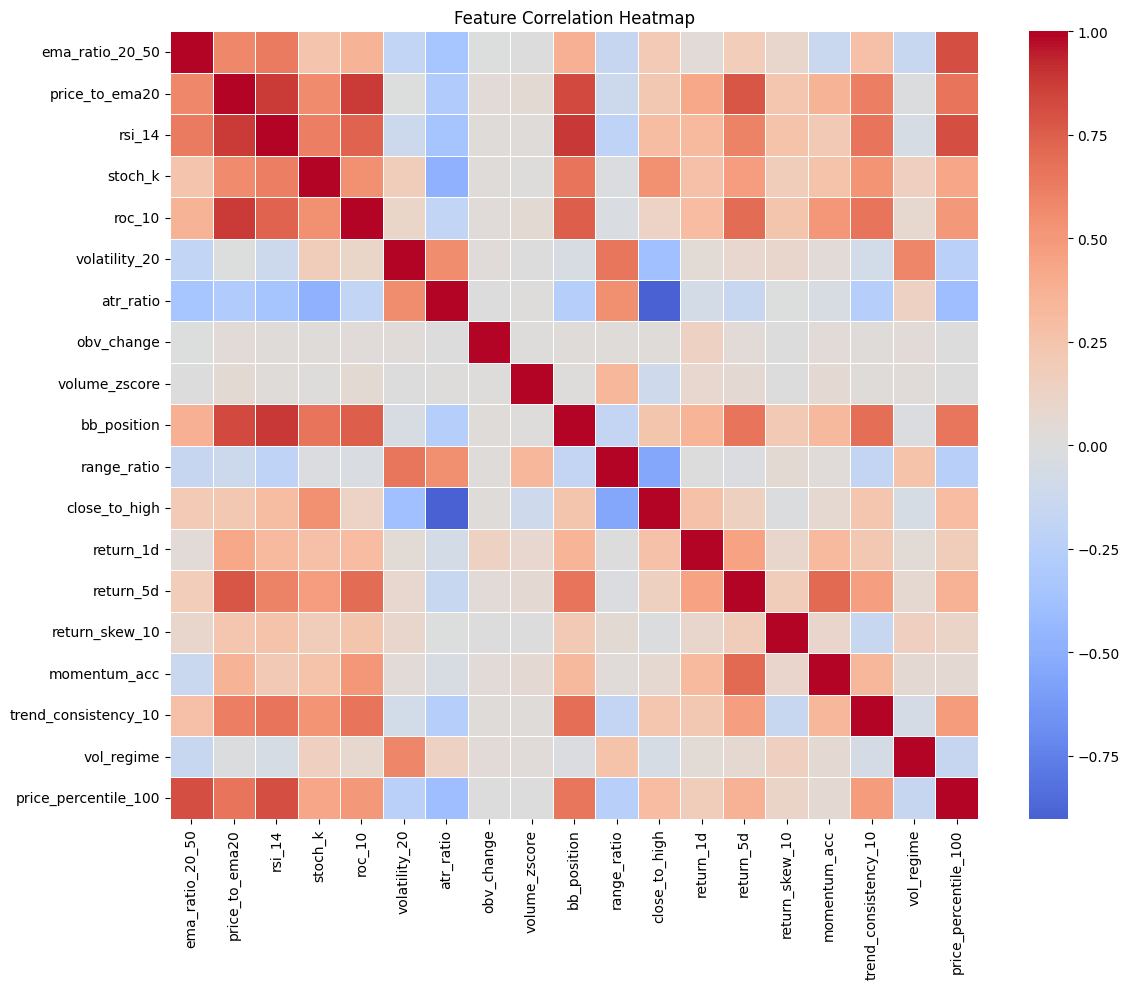

In [425]:
# ===== FEATURE CORRELATION ANALYSIS =====

import seaborn as sns
import matplotlib.pyplot as plt

# Use only selected features
X = df[features]
print(X.info())
# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), cmap="coolwarm", center=0, linewidths=0.5)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Data Preparation: Identifying Redundant Features

This step highlights strongly correlated feature pairs.

- Extract feature pairs with high correlation (>|0.8|)  
- Identify potential redundancy in the feature set  

This supports informed feature selection before modeling.

In [426]:
# ===== HIGH CORRELATION PAIRS =====

corr_matrix = X.corr().abs()

# Get upper triangle (avoid duplicates)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features with high correlation
high_corr = [
    (column, idx, upper.loc[idx, column])
    for column in upper.columns
    for idx in upper.index
    if upper.loc[idx, column] > 0.8
]

print("Highly correlated feature pairs (>|0.8|):")
for f1, f2, corr in high_corr:
    print(f"{f1} ↔ {f2} : {corr:.2f}")

Highly correlated feature pairs (>|0.8|):
rsi_14 ↔ price_to_ema20 : 0.88
roc_10 ↔ price_to_ema20 : 0.88
bb_position ↔ price_to_ema20 : 0.82
bb_position ↔ rsi_14 : 0.89
close_to_high ↔ atr_ratio : 0.90
price_percentile_100 ↔ ema_ratio_20_50 : 0.81
price_percentile_100 ↔ rsi_14 : 0.81


## Data Preparation: Feature Selection

This step refines the engineered feature set by removing redundant and highly correlated features.

- Retain features capturing distinct signals (trend, momentum, volatility, volume, behavioral)
- Remove overlapping indicators to reduce multicollinearity
- Preserve nonlinear features that provide richer market dynamics

The resulting feature set balances information diversity with reduced redundancy for modeling.

In [ ]:
selected_features = [
    # Trend
    "ema_ratio_20_50",
    "bb_position",
    "price_percentile_100",

    # Momentum (nonlinear retained)
    "roc_10",
    "stoch_k",
    "momentum_acc",

    # Volatility
    "volatility_20",
    "atr_ratio",
    "vol_regime",

    # Volume
    "volume_zscore",
    "obv_change",

    # Behavioral
    "trend_consistency_10",

    # Higher-order stats
    "return_skew_10"
]
#Retained 13 features during initial analysis

selected_features = [

    # Trend
    "ema_ratio_20_50",
    "price_percentile_100",

    # Momentum
    "roc_10",
    "momentum_acc",
    #volume
    "obv_change",

    # Volatility
    "volatility_20",

    # Behavioral / nonlinear
    "trend_consistency_10",
    "bb_position",
    "stoch_k"
]
# eliminated features based on multicollinearity and permutation feature importance

## Data Preparation: Defining Features and Target

Separate the dataset into input features (X) and target variable (y).

- Select finalized feature set for modeling  
- Define prediction target  
- Verify data integrity (no missing values, correct alignment)  

This ensures the dataset is ready for model training.

In [428]:
# ===== DEFINE FEATURES AND TARGET =====

X = df[selected_features]
y = df["target"]

# Basic checks
print("Target info:")
print(y.info())

print("\nTarget distribution:")
print(y.value_counts(normalize=True) * 100)

print("\nX-Y index alignment:", (X.index == y.index).all())

print("\nShape of data:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Target info:
<class 'pandas.Series'>
RangeIndex: 6409 entries, 0 to 6408
Series name: target
Non-Null Count  Dtype
--------------  -----
6409 non-null   int64
dtypes: int64(1)
memory usage: 50.2 KB
None

Target distribution:
target
1    61.912935
0    38.087065
Name: proportion, dtype: float64

X-Y index alignment: True

Shape of data:
X shape: (6409, 9)
y shape: (6409,)


## Data Understanding: Feature–Target Relationship

This step evaluates how each feature relates to the prediction target.

- Compute correlation between each feature and the target variable  
- Rank features based on strength of relationship  
- Identify features with stronger predictive signal  

This provides a first indication of feature relevance before modeling.

In [429]:
target_corr = pd.concat([X, y], axis=1).corr()["target"].drop("target").sort_values(ascending=False)
print("\nCorrelation of features with target:")   
print(target_corr)                                                               


Correlation of features with target:
price_percentile_100    0.074720
stoch_k                 0.067537
trend_consistency_10    0.056302
bb_position             0.054174
ema_ratio_20_50         0.054002
roc_10                  0.048485
momentum_acc            0.006344
obv_change             -0.005153
volatility_20          -0.028294
Name: target, dtype: float64


## Modeling: Train–Validation–Test Split

The dataset is split in two stages to balance temporal integrity and model learning:

### 1. Time-based split (80–20)
- First 80% → training + validation  
- Last 20% → final test set  

This ensures that future data is not used during training, preventing data leakage.

### 2. Random train–validation split (within 80%)
- The training portion is further split into train and validation sets using random shuffling  
- This helps obtain a more stable estimate of model performance during training  

A **LogisticRegressionModel** is used as a baseline. Features are standardized using `StandardScaler` due to sensitivity to scale.

Model performance is evaluated in two stages:

- Validation set → used for initial performance assessment  
- Test set → used for final unbiased evaluation  

Metrics used:
- Accuracy, Precision, Recall, F1 Score  
- ROC-AUC for probabilistic evaluation  
- Confusion Matrix and Classification Report  
- ROC Curve visualization  

This setup provides a balance between realistic time-based evaluation and effective model training.

Train+Val size: (5127, 9)
Test size: (1282, 9)
Train size: (3845, 9)
Validation size: (1282, 9)

===== VALIDATION PERFORMANCE =====
Accuracy: 0.5335413416536662
F1 Score: 0.577683615819209

===== FINAL TEST PERFORMANCE =====
Accuracy: 0.6146645865834633
Precision: 0.6727272727272727
Recall: 0.8222222222222222
F1 Score: 0.74
ROC-AUC: 0.5726529438349973

Classification Report:

              precision    recall  f1-score   support

           0       0.36      0.20      0.26       427
           1       0.67      0.82      0.74       855

    accuracy                           0.61      1282
   macro avg       0.52      0.51      0.50      1282
weighted avg       0.57      0.61      0.58      1282

ROC-AUC: 0.5726529438349973


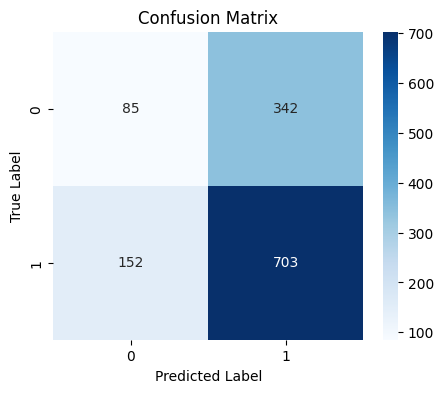

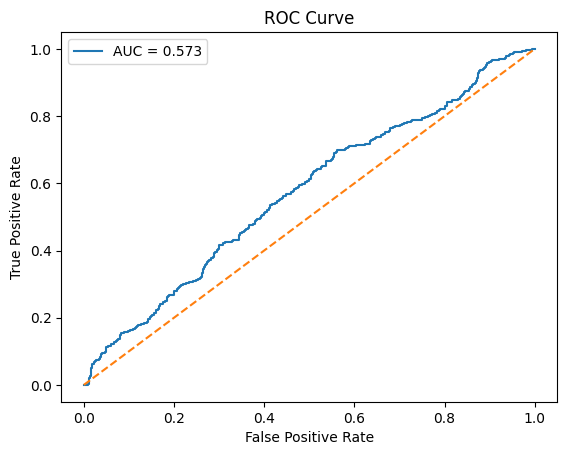

In [430]:
# ===== STEP 1: TIME-BASED TRAIN-TEST SPLIT =====

split_idx = int(len(X) * 0.8)

X_train_full = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train_full = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train+Val size:", X_train_full.shape)
print("Test size:", X_test.shape)


# ===== STEP 2: TRAIN-VALIDATION SPLIT (RANDOM) =====

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    shuffle=True,
    random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)


# ===== SCALING =====

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# ===== MODEL TRAINING =====

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
   
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)


# ===== VALIDATION PERFORMANCE =====

from sklearn.metrics import accuracy_score, f1_score

val_pred = model.predict(X_val_scaled)

print("\n===== VALIDATION PERFORMANCE =====")
print("Accuracy:", accuracy_score(y_val, val_pred))
print("F1 Score:", f1_score(y_val, val_pred))


# ===== FINAL TEST EVALUATION =====

from sklearn.metrics import (
    precision_score, recall_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n===== FINAL TEST PERFORMANCE =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# =========================
# ROC-AUC SCORE
# =========================
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)


# =========================
# CONFUSION MATRIX (VISUAL)
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# =========================
# ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### Modeling: Random Forest

A Random Forest classifier is trained and evaluated using the train–validation–test split.

#### 1. Model setup
- n_estimators = 200  
- max_depth = 6  
- min_samples_split = 20  
- class_weight = "balanced"  
- random_state = 42  

#### 2. Training
- Model is trained on (X_train, y_train)

#### 3. Validation evaluation
- Predictions on X_val
- Metrics:
  - Accuracy
  - F1 Score  

#### 4. Final test evaluation
- Predictions on X_test
- Metrics:
  - Accuracy  
  - Precision  
  - Recall  
  - F1 Score  
  - ROC-AUC  

#### 5. Visual evaluation
- Confusion Matrix  
- ROC Curve


===== VALIDATION PERFORMANCE (RF) =====
Accuracy: 0.6591263650546022
F1 Score: 0.7320662170447578

===== FINAL TEST PERFORMANCE (RF) =====
Accuracy: 0.6482059282371295
Precision: 0.688785046728972
Recall: 0.8619883040935673
F1 Score: 0.7657142857142857
ROC-AUC: 0.5768601832449978

Classification Report:

              precision    recall  f1-score   support

           0       0.44      0.22      0.29       427
           1       0.69      0.86      0.77       855

    accuracy                           0.65      1282
   macro avg       0.57      0.54      0.53      1282
weighted avg       0.61      0.65      0.61      1282



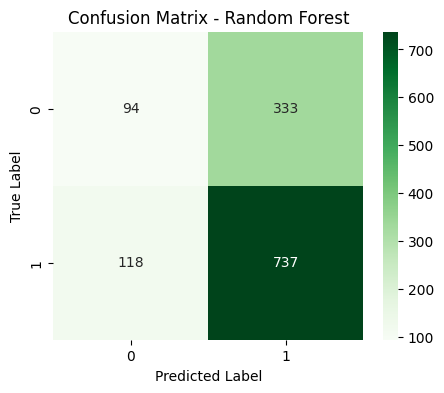

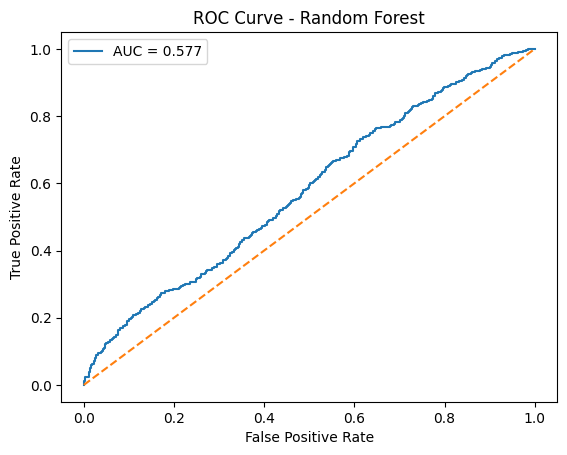

In [431]:
# ===== RANDOM FOREST MODELING =====

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Model ----
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=20,
    random_state=42,
    class_weight="balanced"
)

# ---- Train ----
rf_model.fit(X_train, y_train)

# ---- Validation Performance ----
val_pred = rf_model.predict(X_val)

print("\n===== VALIDATION PERFORMANCE (RF) =====")
print("Accuracy:", accuracy_score(y_val, val_pred))
print("F1 Score:", f1_score(y_val, val_pred))


# ---- Final Test Evaluation ----
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("\n===== FINAL TEST PERFORMANCE (RF) =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# =========================
# CONFUSION MATRIX (VISUAL)
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()


# =========================
# ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

### Modeling: XGBoost

An XGBoost classifier is trained as an advanced model to capture non-linear patterns in the data.

- Trained on (X_train, y_train)  
- Evaluated on validation and test sets  
- Metrics: Accuracy, Precision, Recall, F1, ROC-AUC


===== VALIDATION PERFORMANCE (XGB) =====
Accuracy: 0.6981279251170047
F1 Score: 0.7764298093587522

===== FINAL TEST PERFORMANCE (XGB) =====
Accuracy: 0.672386895475819
Precision: 0.6879861711322386
Recall: 0.9309941520467836
F1 Score: 0.7912524850894632
ROC-AUC: 0.5512825780297739

Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.15      0.24       427
           1       0.69      0.93      0.79       855

    accuracy                           0.67      1282
   macro avg       0.61      0.54      0.52      1282
weighted avg       0.63      0.67      0.61      1282



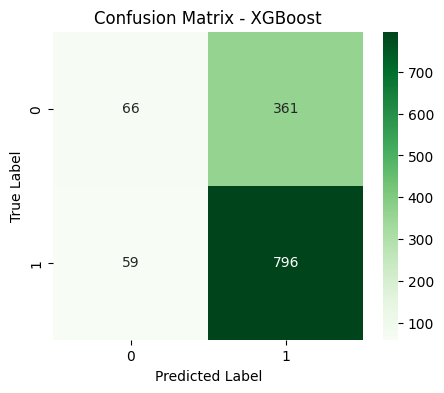

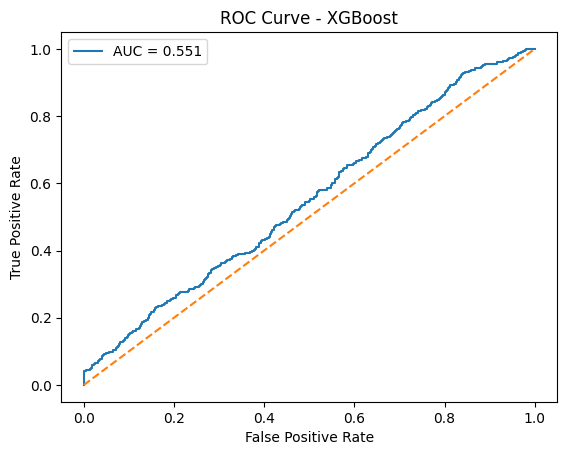

In [432]:
# ===== XGBOOST MODELING =====

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Model ----
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# ---- Train ----
xgb_model.fit(X_train, y_train)

# ---- Validation Performance ----
val_pred = xgb_model.predict(X_val)

print("\n===== VALIDATION PERFORMANCE (XGB) =====")
print("Accuracy:", accuracy_score(y_val, val_pred))
print("F1 Score:", f1_score(y_val, val_pred))


# ---- Final Test Evaluation ----
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("\n===== FINAL TEST PERFORMANCE (XGB) =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# ===============================
# CONFUSION MATRIX (VISUAL)
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost")
plt.show()


# ===============================
# ROC CURVE
# ===============================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

### Prediction Confidence Analysis (XGBoost)

Prediction confidence is computed using model probabilities.

#### 1. Method
- Confidence = distance from 0.5  
- Higher confidence → stronger prediction  

#### 2. Analysis
- Confidence vs correctness (boxplot)  
- Distribution of confidence for correct vs wrong predictions  
- Accuracy across confidence bins  

#### 3. Insight
- Higher confidence predictions are expected to be more accurate  
- Confidence helps identify reliable predictions


===== SAMPLE PREDICTIONS =====

   Actual  Predicted  Probability  Confidence  Correct
0       1          1     0.708209    0.416417     True
1       1          1     0.801199    0.602398     True
2       1          1     0.734968    0.469936     True
3       1          1     0.717075    0.434151     True
4       1          1     0.729197    0.458393     True


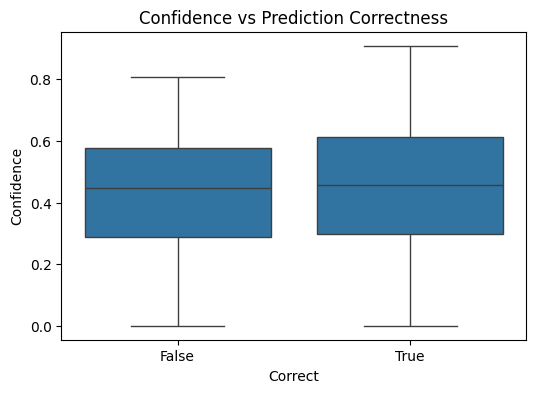

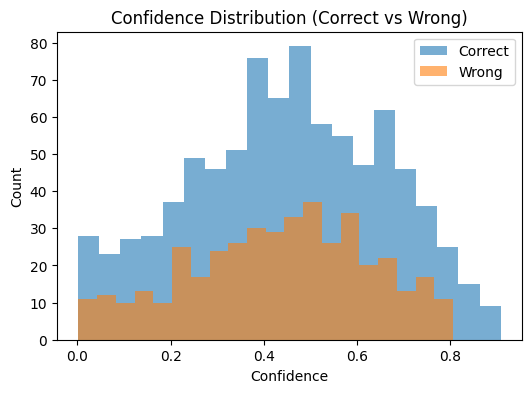


===== ACCURACY BY CONFIDENCE BIN =====

Confidence_Bin
Very Low    0.664122
Low         0.645598
Medium      0.694545
High        0.925000
dtype: float64


In [433]:
# ===== PREDICTION CONFIDENCE ANALYSIS (XGBOOST) =====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Probabilities ----
y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# ---- Confidence ----
confidence = np.abs(y_prob - 0.5) * 2

# ---- Results DataFrame ----
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_prob,
    "Confidence": confidence
})

# ---- Correct / Wrong ----
results_df["Correct"] = results_df["Actual"] == results_df["Predicted"]

print("\n===== SAMPLE PREDICTIONS =====\n")
print(results_df.head())


# ===============================
# 1. CONFIDENCE BY CORRECTNESS
# ===============================
plt.figure(figsize=(6,4))
sns.boxplot(x="Correct", y="Confidence", data=results_df)
plt.title("Confidence vs Prediction Correctness")
plt.show()


# ===============================
# 2. DISTRIBUTION: CORRECT vs WRONG
# ===============================
plt.figure(figsize=(6,4))

plt.hist(results_df[results_df["Correct"]]["Confidence"],
         bins=20, alpha=0.6, label="Correct")

plt.hist(results_df[~results_df["Correct"]]["Confidence"],
         bins=20, alpha=0.6, label="Wrong")

plt.xlabel("Confidence")
plt.ylabel("Count")
plt.title("Confidence Distribution (Correct vs Wrong)")
plt.legend()
plt.show()


# ===============================
# 3. ACCURACY BY CONFIDENCE BIN
# ===============================
bins = [0, 0.4, 0.6, 0.8, 1.0]
labels = ["Very Low", "Low", "Medium", "High"]

results_df["Confidence_Bin"] = pd.cut(results_df["Confidence"], bins=bins, labels=labels)

accuracy_by_bin = results_df.groupby("Confidence_Bin").apply(
    lambda x: (x["Actual"] == x["Predicted"]).mean()
)

print("\n===== ACCURACY BY CONFIDENCE BIN =====\n")
print(accuracy_by_bin)

### Prediction Confidence Analysis (XGBoost)

Model predictions are evaluated based on confidence scores derived from predicted probabilities.

- Confidence = distance from 0.5 probability  
- Predictions grouped into: Very Low, Low, Medium, High  
- Accuracy computed for each confidence level  

High-confidence predictions (> 0.8) are further evaluated to assess model reliability.

In [434]:
high_conf = results_df[results_df["Confidence"] > 0.8]

print("High confidence accuracy:",
      (high_conf["Actual"] == high_conf["Predicted"]).mean())

High confidence accuracy: 0.925


### Feature Importance (Permutation)

Permutation importance evaluates feature contribution by measuring performance drop when features are shuffled.

- Computed on test set  
- Features ranked by importance  
- Higher value → more important


===== PERMUTATION FEATURE IMPORTANCE =====

                feature  importance_mean  importance_std
1  price_percentile_100         0.030109        0.005223
5         volatility_20         0.021841        0.005221
8               stoch_k         0.018565        0.002786
2                roc_10         0.017551        0.003066
0       ema_ratio_20_50         0.011700        0.005415
3          momentum_acc         0.009984        0.003287
7           bb_position         0.009360        0.003625
4            obv_change         0.004914        0.001711
6  trend_consistency_10         0.004368        0.002422


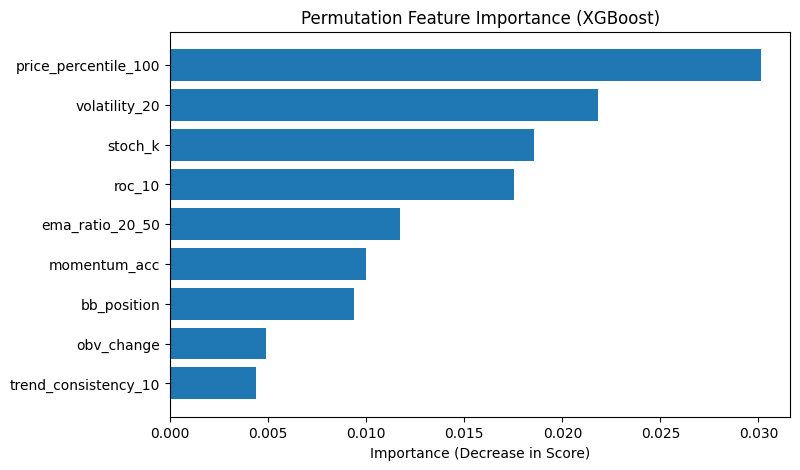

In [ ]:
# ===== PERMUTATION FEATURE IMPORTANCE (XGBOOST) =====

from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# ---- Compute Importance on TEST set ----
perm_importance = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# ---- Create DataFrame ----
feature_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

# ---- Sort ----
feature_importance_df = feature_importance_df.sort_values(
    by="importance_mean",
    ascending=False
)

print("\n===== PERMUTATION FEATURE IMPORTANCE =====\n")
print(feature_importance_df)


# ===============================
# VISUALIZATION
# ===============================
plt.figure(figsize=(8,5))
plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance_mean"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance (Decrease in Score)")
plt.title("Permutation Feature Importance (XGBoost)")

plt.show()
#We went back to our selected_features list and removed two features vol_regime and volume_zscore ,this has improved the model performance